In [1]:
import pandas as pd
import numpy as np

In [2]:


# TASK 1



In [3]:
# Step 1: Load the dataset
df = pd.read_csv("Dataset.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [4]:
# Step 2: Handle the missing values

df['type']=df['type'].fillna('Unknown')
df['title']=df['title'].fillna('Unknown')
df['director']=df['director'].fillna('Unknown')
df['country']=df['country'].replace('Not Given',np.nan)
df['country']=df['country'].fillna(df['country'].mode()[0]) # mode() function calculates the statistical mode,
# which is the value that appears most often in a dataset. 
# [0] A mode function can technically return multiple values if there is a tie.
# Adding [0] ensures that Python selects the very first, top-ranking country from that list. US is appearing on top.
df['date_added']=df['date_added'].str.strip()
df['date_added'] = df['date_added'].fillna('01/01/2021')


In [5]:
# Step 3 : Remove duplicate records and formatting inconsistencies.

df=df.drop_duplicates(subset=['show_id'])

# --- FIXING FORMATTING INCONSISTENCIES ---
df['type'] = df['type'].astype(str).str.title().str.strip()
df['rating'] = df['rating'].astype(str).str.upper().str.strip()
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')


In [6]:
# --- STEP 4: Standardize columns such as Country, Rating, and type

df['type'] = df['type'].astype(str).str.title().str.strip()
df['rating'] = df['rating'].astype(str).str.upper().str.strip()
df['country'] = df['country'].astype(str).str.title().str.strip()



In [7]:
# step5:Export the cleaned dataset for analysis

df=df.to_csv("cleaned_netflix_titles.csv", index=False)
print("Data Cleaning Complete. Missing values handled professionally.")

Data Cleaning Complete. Missing values handled professionally.


In [8]:



# TASK 2


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#  step 1 : load the clean data set 
df=pd.read_csv("cleaned_netflix_titles.csv")
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [11]:
# step 2: Calculate the total number of Movies and TV Show

content_counts = df['type'].value_counts()
print("The total Movie and TV Shows Count are:",
      content_counts)


The total Movie and TV Shows Count are: type
Movie      6126
Tv Show    2664
Name: count, dtype: int64


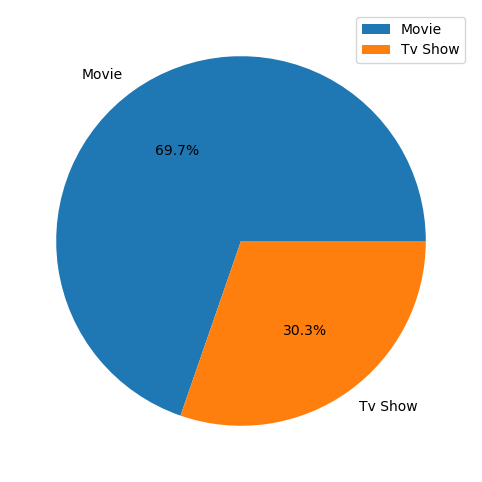

In [12]:
#  step 3 :Create visualizations for content distribution

plt.figure(figsize=(8, 6))
plt.pie(content_counts, labels=content_counts.index, autopct='%1.1f%%')
plt.legend()
plt.show()


In [13]:
# step  4: : Compare content proportions.

# 1. Get raw counts and calculate percentages simply
raw_counts = df['type'].value_counts()
proportions = df['type'].value_counts(normalize=True) * 100

print("       NETFLIX CONTENT TYPE DISTRIBUTION          ")

# Loop through categories (Movie and TV Show) simply
for category in raw_counts.index:
    count = raw_counts[category]
    percentage = proportions[category]
    
    print(f"• {category}: {count} titles ({percentage:.2f}%)")



       NETFLIX CONTENT TYPE DISTRIBUTION          
• Movie: 6126 titles (69.69%)
• Tv Show: 2664 titles (30.31%)


In [14]:
# Step 5 : Summarize key findings

 # Capital Allocation & Inventory Volumetrics
# -> The numerical dominance of Movies (69.69% of total catalog volume) vs. TV Shows (30.31%) highlights a specific content-acquisition strategy.
# Movies require a lower initial long-term operational commitment per title compared to multi-season TV series.
# Historically, stocking the library with feature films allowed Netflix to rapidly scale its 
# total library volume, creating a massive storefront of choice for subscriber acquisition across diverse demographics.

In [15]:


# Task 3: Country- wise Netflix content analysis




In [16]:
# Step 1: Extract and clean country information.

df=pd.read_csv("cleaned_netflix_titles.csv")

df['country']=df['country'].astype(str).str.split(', ')

exploded_df=df.explode('country')
exploded_df['country'] = exploded_df['country'].str.strip()
print(f"Original dataset rows: {df.shape[0]}")
print(f"Expanded country-level rows after extraction: {exploded_df.shape[0]}")


Original dataset rows: 8790
Expanded country-level rows after extraction: 8790


In [17]:
# step 2 Step 2: Calculate content count by country.
df=pd.read_csv("cleaned_netflix_titles.csv")
clean_countries=df['country'].str.split(', ').explode()
country_aggregates=clean_countries.value_counts()
print(f"Content Counts Aggregated by country:{country_aggregates.head(10)}")


Content Counts Aggregated by country:country
United States     3527
India             1057
United Kingdom     638
Pakistan           421
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Mexico             138
Name: count, dtype: int64


In [18]:
# step 3:Step 3: Identify top content-producing countries.
# Here i simply find the top 5 country produce top content 
country_aggregates.head()

country
United States     3527
India             1057
United Kingdom     638
Pakistan           421
Canada             271
Name: count, dtype: int64

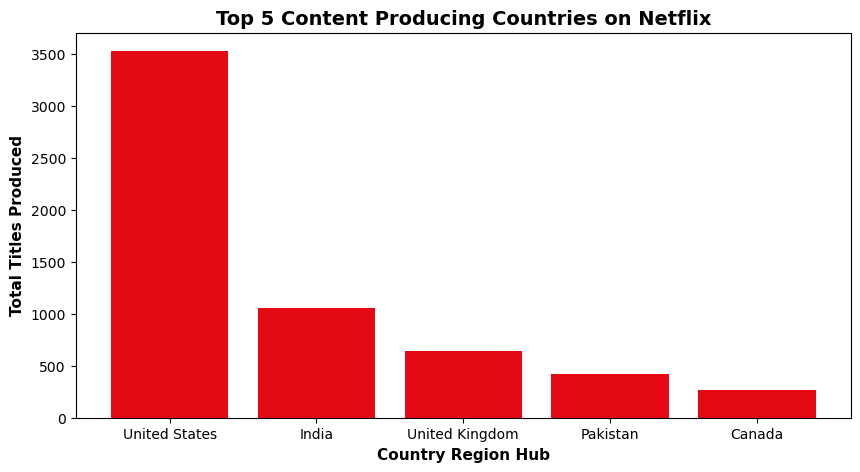

In [19]:
# Step 4: Create charts and rankings.

# here i generate the chart by using barchart of top 5  higest rank countries

top_5_ranking=country_aggregates.head()
plt.figure(figsize=(10,5))
plt.bar(top_5_ranking.index,top_5_ranking.values,color='#E50914')
plt.title("Top 5 Content Producing Countries on Netflix", fontsize=14, weight='bold')
plt.xlabel("Country Region Hub", fontsize=11, weight='bold')
plt.ylabel("Total Titles Produced", fontsize=11, weight='bold')
plt.show()

In [20]:
# Step 5: Generate business insights.

# from above bar chart cleary visible The overwhelming dominance of the United States as the premier content cluster
# underscores a core operational reality:Netflix’s content engine remains structurally anchored in Hollywood infrastructure

# ->The emergence of heavyweights like India, the United Kingdom,pakistan and canada  as top production
#   tier countries reflects a transition from global distribution to Hyper-Localization.

# The Maturity Strategy (UK & Europe): -> Investing in the UK and European ecosystems allows Netflix to capture highly exportable,
#                                        premium English-language and cross-continental dramas that achieve a strong return on invested capital (ROI) 
#                                        across both Western and non-Western subscriber bases.


# The Non-Western Acquisition Engine (India & APAC):-> High-volume outputs in regions like India represent direct consumer acquisition tactics.
#                                                     In these markets, subscriber growth is heavily dependent on localized cultural resonance.
#                                                     By establishing regional production hubs, the company converts local cultural narratives into a
#                                powerful subscriber engine, driving down customer acquisition costs (CAC) in high-population, mobile-first territories.

In [21]:



# Task 4



In [22]:
# Step 1: Organize content by release year.
df=pd.read_csv("cleaned_netflix_titles.csv")


# trying to filterout the old dated movie but i provide you the first movie and TV show.
modern_df=df[df['release_year']>=2000]
organized_df=modern_df.groupby(['release_year','type']).size()
print("Organize content by release year")
print(organized_df.head(10))

print("---------------------------------------------")
print("The first movie and Tv show:")
first_df=df.groupby('type').agg({'release_year':'min','title':'first'})
first_df

Organize content by release year
release_year  type   
2000          Movie      33
              Tv Show     4
2001          Movie      40
              Tv Show     5
2002          Movie      44
              Tv Show     7
2003          Movie      51
              Tv Show     8
2004          Movie      55
              Tv Show     9
dtype: int64
---------------------------------------------
The first movie and Tv show:


,release_year,title
type,,
Movie,1942,Dick Johnson Is Dead
Tv Show,1925,Ganglands


In [23]:

# Step 2: Calculate yearly content releases.

# Filter for modern titles (Year 2000 to present) to keep data focused
modern_df = df[df['release_year'] >= 2000]
yearly_content_df=modern_df.groupby(['release_year','type']).size().unstack()
yearly_content_df.head(10)

type,Movie,Tv Show
release_year,,
2000,33,4
2001,40,5
2002,44,7
2003,51,8
2004,55,9
2005,67,13
2006,82,14
2007,74,14
2008,113,22


In [24]:
# Step 3: Identify growth and decline trends.

#  -> to find the growth and decline trend i need to evaluated yealy to yealry growing rate of movie and tv shows
#      so used pct_change() function to calculate the change from one year to the next. 

growth_trend=yearly_content_df.pct_change() *100
print("---  Year-over-Year Growth/Decline Trends (%) ---")
print(growth_trend.tail(10).round(2))

---  Year-over-Year Growth/Decline Trends (%) ---
type          Movie  Tv Show
release_year                
2012          19.31    57.50
2013          30.06    -3.17
2014          17.33    44.26
2015          50.00    80.68
2016          66.16    52.83
2017          16.26     9.05
2018           0.26    43.02
2019         -17.47     4.75
2020         -18.33     9.82
2021         -46.42   -27.75


In [25]:
# The year 2015 and 2016 represent the most explosive period of growth in Netflix’s history for both formats.
# In 2015, Movie output grew by 50.00% and TV Shows skyrocketed by 80.68%. 
# This velocity continued into 2016 with Movies peaking at massive 66.16% growth rate and TV shows decline to 52.83% but this is good growth for netflix.

# The Great Strategy Pivot (2013)
  # ->  In 2013, Movie production grew significantly (30.06%), 
#       while TV Shows experienced a clear decline of -3.17%.
    # -> This represents a brief historical moment where Netflix focused on acquiring massive
      # Hollywood movie licensing blocks before shifting its long-term financial focus heavily back into serialized multi-season series.
#    in next year 2014 clearly see TV Shows growth by 44.26%.

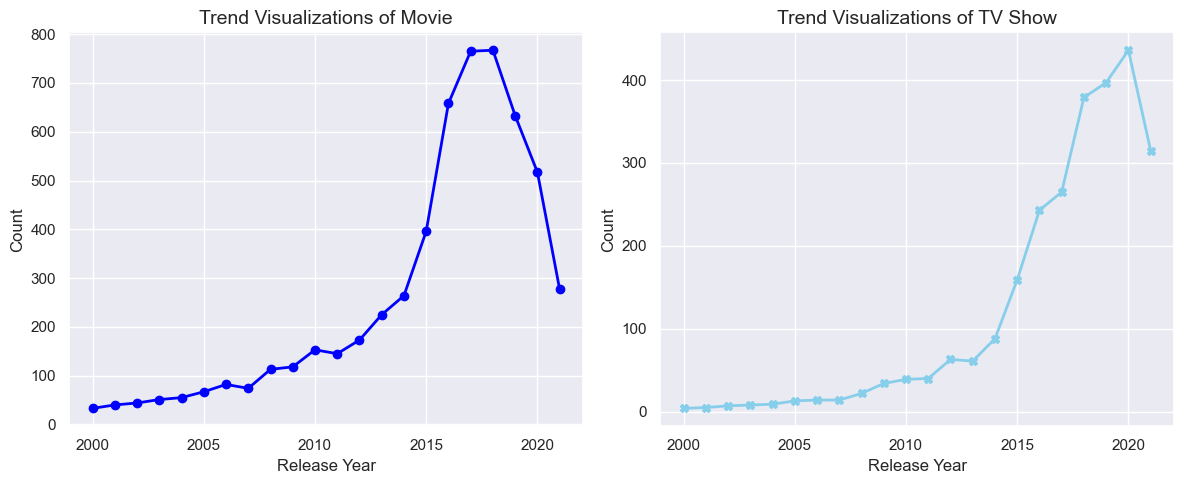

In [26]:
# Step 4: Create charts and rankings.

sns.set_theme()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) 
plt.plot(yearly_content_df.index, yearly_content_df['Movie'], color='blue', marker='o', linewidth=2)
plt.title("Trend Visualizations of Movie", fontsize=14)
plt.xlabel("Release Year")
plt.ylabel("Count")

#  plot for TV show
plt.subplot(1, 2, 2)
plt.plot(yearly_content_df.index, yearly_content_df['Tv Show'], color='skyblue', marker='X', linewidth=2)
plt.title("Trend Visualizations of TV Show", fontsize=14)
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



In [27]:
# step 5

# While both mediums exhibit upward trajectories, their operational velocity and growth curves differ significantly.

# The Pattern: Movie production volumes scale aggressively, showing steeper vertical spikes in short cycles.
#              Conversely, TV Show growth is more deliberate, incremental, and stable year-over-year.
 #             Sharp, sudden drops or plateaus in both line graphs during identical chronological windows 
#              (e.g., historical periods like the 2007–2008 financial crisis, the 2020 global pandemic, or major industry labor strikes).

# Movies are transactional and high-risk/high-reward:
#         -> Production companies aggressively ramp up output to diversify their portfolio.
#            If one blockbuster fails, three others might cover the costs.
  
#  TV Shows are relational asset engines.
         #     ->A television series requires sustained, multi-year financial commitments (renewals, recurring talent contracts).

In [28]:


# Task 5



--- Content Volume by Rating Category ---
type      Movie  Tv Show  Total
rating                         
TV-MA      2003     1137   3140
TV-14      1302      717   2019
TV-PG       494      308    802
R           678        2    680
PG-13       411        0    411
TV-Y7       139      183    322
TV-Y        131      173    304
PG          236        0    236
TV-G        122       86    208
NR           68        4     72
G            23        0     23
TV-Y7-FV      5        1      6
NC-17         3        0      3
UR            2        0      2


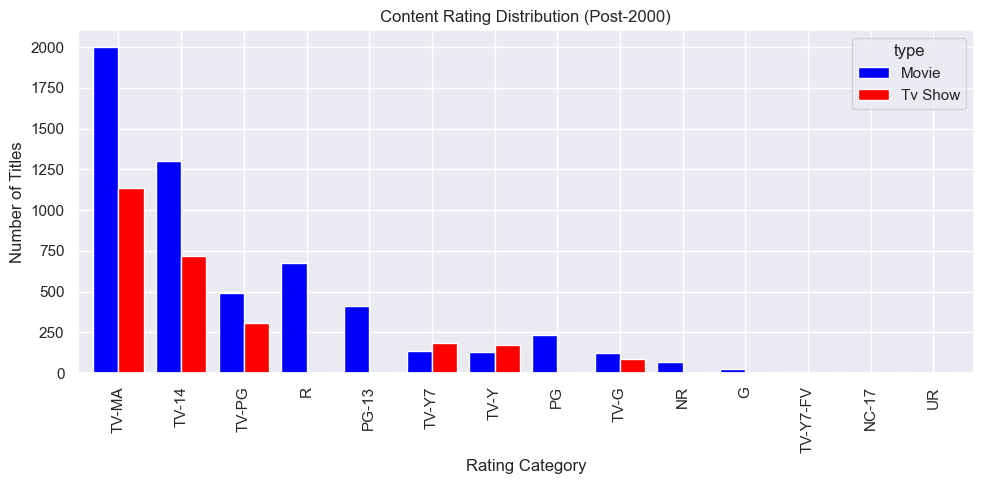

In [29]:
# Step 1: Analyze rating categories.

df=pd.read_csv("cleaned_netflix_titles.csv")

modern_df = df[df['release_year'] >= 2000]
yearly_content_df=modern_df.groupby(['release_year','type']).size().unstack()

# 1. Filter data and handle missing ratings cleanly
df_modern = modern_df[modern_df['release_year'] > 2000].copy()
df_modern['rating'] = df_modern['rating'].fillna('Unrated')

rating_table = df_modern.groupby(['rating', 'type']).size().unstack(fill_value=0)
rating_table = rating_table.assign(Total=rating_table.sum(axis=1)).sort_values('Total', ascending=False)

print("--- Content Volume by Rating Category ---")
print(rating_table)


# Chart styling
chart_data=rating_table.drop(columns=["Total"])
chart_data.plot(kind="bar",figsize=(10, 5), width=0.8,color=["blue",'red'])
sns.set_theme(style="whitegrid")
plt.title("Content Rating Distribution (Post-2000)")
plt.xlabel("Rating Category")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


In [30]:
# Content Rating Portfolio Analysis

  # -> Core Market Focus: The platform's content portfolio is heavily anchored in adult and young adult demographics. 
#                     TV-MA is the dominant rating category across both mediums, followed closely by TV-14.
#                   This distribution confirms a deliberate corporate strategy to invest
#                  in mature, high-engagement, prestige programming to drive subscription stickiness and adult viewer retention.

# ->   Structural Bifurcation by Medium: Content types follow separate regulatory supply chains. Feature films are diversified across 
#                                       standard cinematic classifications (R, PG-13, and PG), allowing for individual transactional consumption. 
#                                   In contrast, episodic series cluster almost exclusively in streaming-optimized broadcast 
#                                    brackets (TV-MA, TV-14, and TV-PG) to feed continuous, habit-forming viewing loops.

# -> Low-Risk Portfolio Governance: Extreme, or unclassified segments (G, NC-17, NR, and UR) make up a negligible fraction of the catalog.
#                                   This clean "long-tail" distribution minimizes international censorship friction, simplifies the deployment 
                                 # of global parental controls, and protects corporate brand equity as the platform scales.

=== TOP GENRE CATEGORIES BY CONTENT TYPE (POST-2000) ===
type                      Movie  Tv Show  Total
genres_cleaned                                 
International Movies       2580        0   2580
Dramas                     2202        0   2202
Comedies                   1506        0   1506
International TV Shows        0     1343   1343
Documentaries               841        0    841
TV Dramas                     0      757    757
Independent Movies          718        0    718
Action & Adventure          712        0    712
Children & Family Movies    599        0    599
Romantic Movies             567        0    567
TV Comedies                   0      559    559
Thrillers                   549        0    549
Crime TV Shows                0      467    467
Kids' TV                      0      429    429
Docuseries                    0      390    390


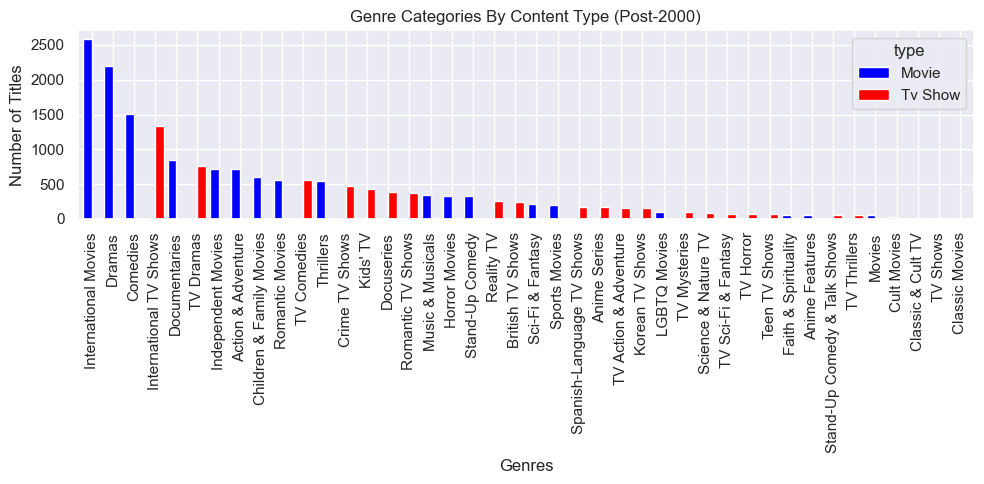

In [31]:
# Step 2: Identify the most common genres.

df_genres=modern_df[modern_df['release_year']>2000].copy()
df_genres['listed_in']=df_genres['listed_in'].fillna('Unknown Genres')
exploded_genres=df_genres.assign(genres_cleaned=df['listed_in'].str.split(', ')).explode('genres_cleaned')
genre_data=exploded_genres.groupby(['genres_cleaned','type']).size().unstack(fill_value=0)
genre_data['Total']=genre_data['Movie']+ genre_data['Tv Show']
genre_data_sorted=genre_data.sort_values(by='Total', ascending=False)
print("=== TOP GENRE CATEGORIES BY CONTENT TYPE (POST-2000) ===")
print(genre_data_sorted.head(15))

# Visualization
sns.set_theme()
chart_data=genre_data_sorted.drop(columns=["Total"])
chart_data.plot(kind="bar",figsize=(10, 5), width=0.8,color=["blue",'red'])
sns.set_theme(style="whitegrid")
plt.title("Genre Categories By Content Type (Post-2000)")
plt.xlabel("Genres")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


In [32]:
# Global Scaling Architecture: The portfolio is heavily anchored by International Movies and International TV Shows, 
#                              which represent the largest volume pillars on the platform. This pattern confirms an aggressive global expansion 
#                              strategy designed to secure localized market penetration, lower international subscriber acquisition costs, 
#                               and meet cross-border regulatory compliance.

#    Mass-Appeal Baseline:      Standard Dramas and Comedies serve as the primary foundational content for broad-market retention. 
#                              The company focuses capital heavily on high-volume film slates in these categories to provide low-friction,
#                              mass-appeal content that stabilizes daily active user traffic.

# Format-Specific Monetization: Content production is strictly optimized by format to match consumer psychology. 
#                              Single-sitting artistic or narrative assets are funneled into singular Movies 
#                              (e.g., Documentaries, Independent Films), while high-retention, habit-forming categories are built exclusively as 
#                        episodic TV Shows (e.g., Kids' TV, Docuseries, Reality TV) to drive continuous binge loops and maximize customer lifetime value.

type      Movie  Tv Show  Total
rating                         
TV-MA     35.66    43.55  38.16
TV-14     23.18    27.46  24.54
TV-PG      8.79    11.80   9.75
R         12.07     0.08   8.26
PG-13      7.32     0.00   5.00
TV-Y7      2.47     7.01   3.91
TV-Y       2.33     6.63   3.69
PG         4.20     0.00   2.87
TV-G       2.17     3.29   2.53
NR         1.21     0.15   0.88
G          0.41     0.00   0.28
TV-Y7-FV   0.09     0.04   0.07
NC-17      0.05     0.00   0.04
UR         0.04     0.00   0.02


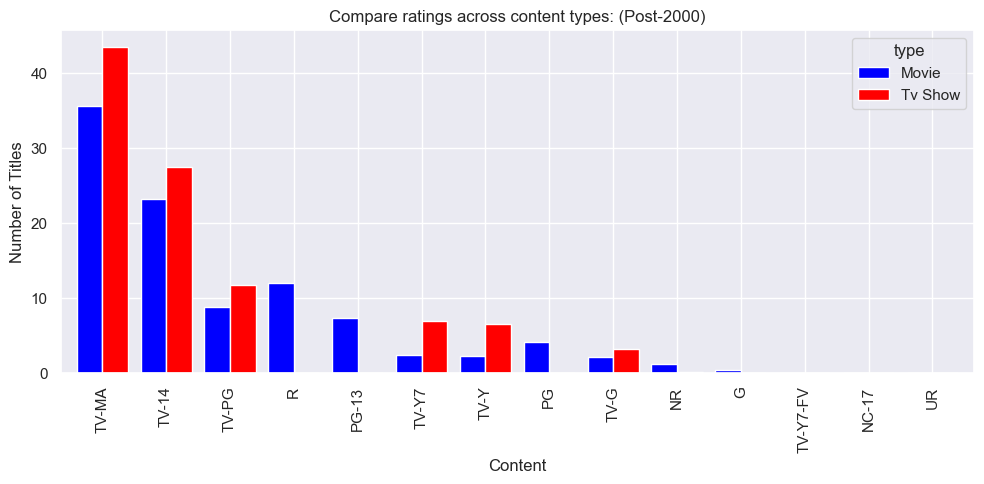

In [33]:
# Step 3: Compare ratings across content types.

df_compare=modern_df[modern_df['release_year']>2000].copy()
df_compare['rating']=df_compare['rating'].fillna("Unrated")
compare_table = df_compare.groupby(['rating', 'type']).size().unstack(fill_value=0)
compare_table = compare_table.assign(Total=compare_table.sum(axis=1)).sort_values('Total', ascending=False)
compare_table_pct = compare_table.div(compare_table.sum(axis=0), axis=1) * 100
print(compare_table_pct.round(2))

# visulaization
sns.set_theme()
chart_data=compare_table_pct.drop(columns=["Total"])
chart_data.plot(kind="bar",figsize=(10, 5), width=0.8,color=["blue",'red'])
plt.title("Compare ratings across content types: (Post-2000)")
plt.xlabel("Content")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


In [34]:
#         The Pattern:   Youth-oriented categories (TV-MA,TV-14,TV-PG, TV-Y7, TV-Y) generally represent a higher relative percentage of the TV Show
#                      catalog than they do for the Movie catalog.High percentage shares for both mediums in overlapping brackets like TV-MA and TV-14.


 #                   International Movies and International TV Shows represent the largest individual genre segments. 
#                   This confirms a highly successful global expansion playbook aimed at accelerating overseas market penetration, 
#                     satisfying localized licensing regulations,and lowering overall subscriber acquisition costs.

In [35]:
# step 5

# 1. Core Target Demographics (Adults & Mature Teens)
  # ->   The massive concentration of TV-MA and TV-14 content establishes the platform's primary consumer profile.
        # The Insight: The core user base consists of Adults (Ages 18–49) and Older Adolescents (Ages 14–17).
#        Corporate Value: Mature, prestige programming drives the highest subscriber stability, generates cultural conversation, 
#                         and sustains long-term platform engagement.

# 2. Global Market Expansion (Low Cultural Friction)
   # -> The dominance of International Movies and TV Shows confirms that the platform's growth is no longer dependent on a single domestic market.
        # The Insight: Modern audiences possess an accelerating appetite for localized and foreign-language narratives,
#                       reducing traditional cultural viewing friction.
#         Business Imperative: By scaling international libraries, the platform transitions from a centralized
#                              export model to a decentralized, global network. This directly addresses subscriber growth 
#                             caps in saturated domestic markets and provides a diverse content portfolio that buffers against localized subscriber churn.

